In [1]:
import os
from functools import partial

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from configs import Configs
configs = Configs()

from matplotlib import rcParams
rcParams.update({
    "font.size": 16,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans", "Liberation Sans"],
    "xtick.direction": "in",
    "ytick.direction": "in",
})



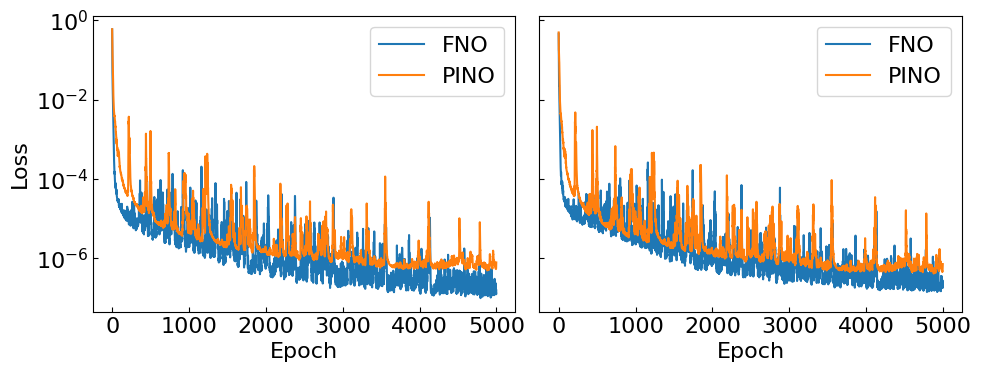

In [9]:
# read csv loss
import pandas as pd
save_dir_fno = "./runs/FNO/"
save_dir_pino = "./runs/PINO/"
loss_df_fno = pd.read_csv(os.path.join(save_dir_fno, "logs.csv"))
loss_df_pino = pd.read_csv(os.path.join(save_dir_pino, "logs.csv"))
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
ax = axes[0]
ax.plot(loss_df_fno["Epoch"], loss_df_fno["TrainLoss"], label="FNO")
ax.plot(loss_df_pino["Epoch"], loss_df_pino["TrainLoss"], label="PINO")
ax.legend()
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")

ax = axes[1]
ax.plot(loss_df_fno["Epoch"], loss_df_fno["ValidLoss"], label="FNO")
ax.plot(loss_df_pino["Epoch"], loss_df_pino["ValidLoss"], label="PINO")
ax.legend()
ax.set_yscale("log")
ax.set_xlabel("Epoch")

fig.tight_layout()

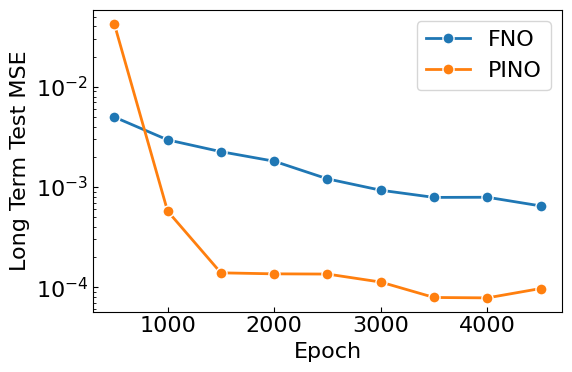

In [17]:
test_df_fno = pd.read_csv(os.path.join(save_dir_fno, "test_logs.csv"))
test_df_pino = pd.read_csv(os.path.join(save_dir_pino, "test_logs.csv"))
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(test_df_fno["Epoch"], test_df_fno["TestMSE"], label="FNO",
        marker='o', markersize=8, markeredgecolor="white", lw=2)
ax.plot(test_df_pino["Epoch"], test_df_pino["TestMSE"], label="PINO",
        marker='o', markersize=8, markeredgecolor="white", lw=2)
ax.legend()
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Long Term Test MSE")
fig.tight_layout()

In [23]:
test_results_fno = jnp.load(os.path.join(save_dir_fno, "test_results.npz"))
y_test_fno = test_results_fno["y_test"]
y_test_pred_fno = test_results_fno["y_test_pred"]
error_fno = jnp.abs(y_test_fno - y_test_pred_fno)
mean_error_fno = jnp.mean(error_fno, axis=(2,3))
test_results_pino = jnp.load(os.path.join(save_dir_pino, "test_results.npz"))
y_test_pino = test_results_pino["y_test"]
y_test_pred_pino = test_results_pino["y_test_pred"]
error_pino = jnp.abs(y_test_pino - y_test_pred_pino)
mean_error_pino = jnp.mean(error_pino, axis=(2,3))
mean_error_fno.shape, mean_error_pino.shape

((6, 100), (6, 100))

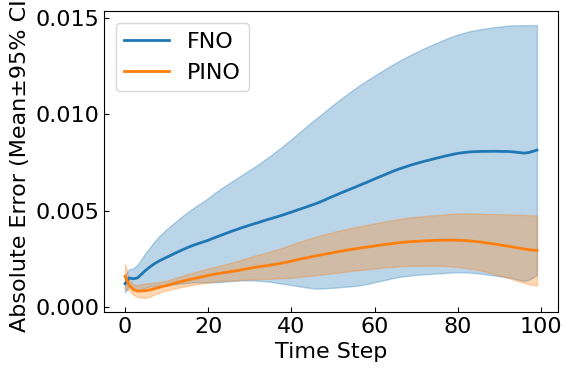

In [37]:
def plot_mean_with_std(ax, data, color, label):
    mean = jnp.mean(data, axis=0)
    std = jnp.std(data, axis=0, ddof=1)
    sem = std / jnp.sqrt(data.shape[0])
    ax.plot(mean, lw=2, color=color, label=label)
    ax.fill_between(
        jnp.arange(data.shape[1]),
        mean - 1.96 * sem,
        mean + 1.96 * sem,
        alpha=0.3,
        color=color
    )
    
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_mean_with_std(ax, mean_error_fno, color="C0", label="FNO")
plot_mean_with_std(ax, mean_error_pino, color="C1", label="PINO")
ax.legend()
ax.set_ylabel("Absolute Error (Mean±95% CI)")
ax.set_xlabel("Time Step")
fig.tight_layout()